In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df=pd.read_csv("House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
print(f"Data shape: {df.shape}")
print(f"Data info: {df.info()}")


Data shape: (2000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
Data info: None


In [4]:
print(f"Data describe:\n{df.describe()}")

Data describe:
                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  999656.000000  


In [5]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Id           0.0
Area         0.0
Bedrooms     0.0
Bathrooms    0.0
Floors       0.0
YearBuilt    0.0
Location     0.0
Condition    0.0
Garage       0.0
Price        0.0
dtype: float64

In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [7]:
print(df.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


In [8]:
df.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

In [9]:
print(f"location value count:\n{df.Location.value_counts()}")
print(f"Condition value count:\n{df.Condition.value_counts()}")
print(f"Garage value count:\n{df.Garage.value_counts()}")


location value count:
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition value count:
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64
Garage value count:
Garage
No     1038
Yes     962
Name: count, dtype: int64


In [10]:
numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]

In [11]:
categorical_features = [
    "Location",
    "Condition",
    "Garage"
]

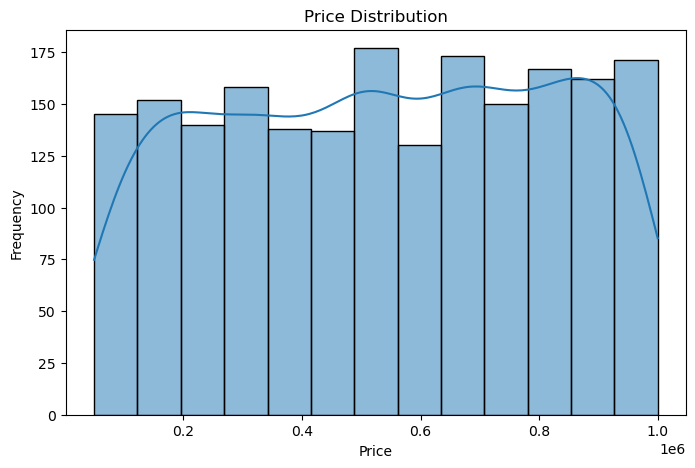

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Price"], kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

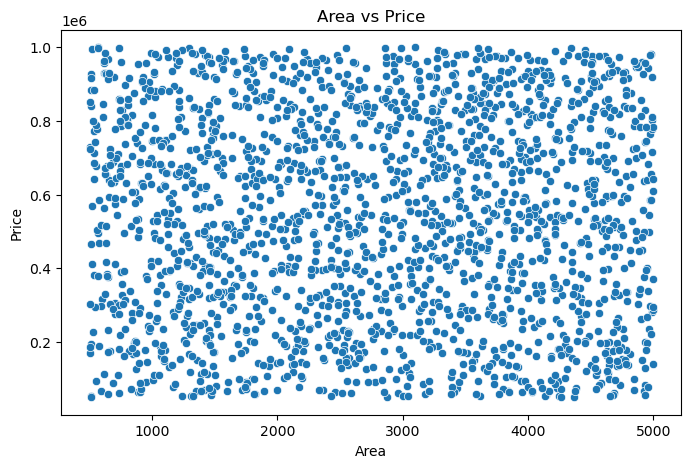

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Area",
    y="Price"
)

plt.title("Area vs Price")

plt.show()

In [18]:
correlation = df[numerical_features + ["Price"]].corr()

correlation

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


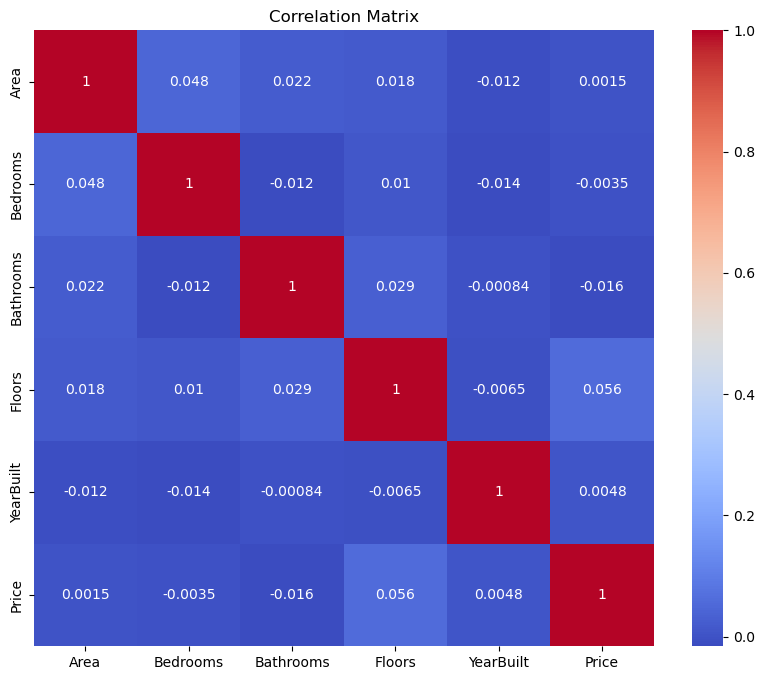

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [14]:
y=df["Price"]
x= df.drop("Price", axis=1)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

print(x_train.head())

(1600, 9)
(400, 9)
(1600,)
(400,)
      Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
968  969  4483         4          4       3       1933     Urban  Excellent   
240  241  1062         3          3       1       1970  Downtown       Good   
819  820  1422         3          4       1       1993     Urban       Good   
692  693  2658         2          3       1       1972     Rural       Poor   
420  421  3286         2          4       1       1981     Rural  Excellent   

    Garage  
968     No  
240     No  
819    Yes  
692    Yes  
420    Yes  
